<h2 style="text-align: center;">Glucose Tolerance and Aging: A Statistical Analysis</h2>
<div style="text-align: center;">Descriptive and Inferential Statistics Project</div>


In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

In [2]:
df = pd.read_excel(r"EVALMASTER.xlsx")

# Part 1: Descriptive Statistics

The glucose tolerance test measures the body's response to sugar and is used as a screening tool for type 2 diabetes. This study examines whether glucose tolerance decreases with age — that is, whether the body takes longer to clear glucose as we age.

A 100 g oral glucose dose was administered to two randomly selected groups of healthy patients:

- **Group 1** (young): age < 30 years
- **Group 2** (adults): age > 30 years

The recorded variables are:

- **Nivel glucosa basal**: blood concentration at the time of the initial reading (mg/dL)
- **Nivel glucosa 60 min**: blood concentration one hour after intake (mg/dL)


In [3]:
grupo_1 = df[df["Grupo de control"] == 1]
grupo_2 = df[df["Grupo de control"] == 2]

In [4]:
grupo_1.head()

,Grupo de control,Nivel glucosa basal,Nivel glucosa 60 min
0,1,90,159
1,1,82,151
2,1,80,148
3,1,75,138
4,1,74,141


## a) Central tendency and dispersion measures — Nivel glucosa basal

Central tendency measures (mean, median, mode) and dispersion measures (standard deviation, variance, range, IQR) are computed for both groups. The **coefficient of variation (CV = s/x̄)** is used to check whether the mean is representative: if CV < 0.30 (30%), the mean is considered representative.

In [5]:
# 1. Central tendency measures

media_1, moda_1, mediana_1 = grupo_1['Nivel glucosa basal'].mean(), grupo_1['Nivel glucosa basal'].mode()[0], grupo_1['Nivel glucosa basal'].median()
media_2, moda_2, mediana_2 = grupo_2['Nivel glucosa basal'].mean(), grupo_2['Nivel glucosa basal'].mode()[0], grupo_2['Nivel glucosa basal'].median()
print("Central tendency measures:")
print(f"Group 1 - Mean: {media_1:.2f}, Mode: {moda_1}, Median: {mediana_1:.2f}")
print(f"Group 2 - Mean: {media_2:.2f}, Mode: {moda_2}, Median: {mediana_2:.2f}")

# 2. Dispersion measures
desviacion_1, varianza_1, rango_1, iqr_1 = grupo_1['Nivel glucosa basal'].std(), grupo_1['Nivel glucosa basal'].var(), grupo_1['Nivel glucosa basal'].max() - grupo_1['Nivel glucosa basal'].min(), stats.iqr(grupo_1['Nivel glucosa basal'])
desviacion_2, varianza_2, rango_2, iqr_2 = grupo_2['Nivel glucosa basal'].std(), grupo_2['Nivel glucosa basal'].var(), grupo_2['Nivel glucosa basal'].max() - grupo_2['Nivel glucosa basal'].min(), stats.iqr(grupo_2['Nivel glucosa basal'])
print("\nDispersion measures:")
print(f"Group 1 - Standard deviation: {desviacion_1:.2f}, Variance: {varianza_1:.2f}, Range: {rango_1}, IQR: {iqr_1}")
print(f"Group 2 - Standard deviation: {desviacion_2:.2f}, Variance: {varianza_2:.2f}, Range: {rango_2}, IQR: {iqr_2}")


Medidas de centralización:
Grupo 1 - Media: 84.69, Moda: 75, Mediana: 82.00
Grupo 2 - Media: 89.40, Moda: 88, Mediana: 90.00

Medidas de dispersión:
Grupo 1 - Desviación estándar: 8.84, Varianza: 78.22, Rango: 38, IQR: 12.0
Grupo 2 - Desviación estándar: 7.35, Varianza: 53.97, Rango: 27, IQR: 9.5


In [6]:
# Is the mean representative of the population?
# 1. Group 1
cv_1 = desviacion_1 / media_1
print("\nGroup 1:")
print(f"Coefficient of variation: {cv_1:.2f}")




Grupo 1:
Coeficiente de variación: 0.10


**Group 1 — Young (age < 30)**

The coefficient of variation obtained is CV = 10%, well below the 30% threshold. This indicates that the data is homogeneous and relative dispersion is low.

**Conclusion:** The mean basal glucose level of Group 1 is representative of the young population.

In [7]:
cv_2 = desviacion_2 / media_2


print("\nGroup 2:")
print(f"Coefficient of variation: {cv_2:.2f}")




Grupo 2:
Coeficiente de variación: 0.08


**Group 2 — Adults (age > 30)**

The coefficient of variation obtained is CV = 8%, even lower than Group 1's. Relative dispersion is very low, reflecting a highly homogeneous dataset.

**Conclusion:** The mean basal glucose level of Group 2 is representative of the adult population.

## b) Skewness and kurtosis — Nivel glucosa basal, Group 2

The shape of the basal glucose distribution in adults is studied using the skewness and kurtosis statistics.

In [8]:
skew_2 = grupo_2['Nivel glucosa basal'].skew()
curtosis_2 = grupo_2['Nivel glucosa basal'].kurtosis()
print(f"Group 2 - Skewness: {skew_2:.2f}")
print(f"Group 2 - Kurtosis: {curtosis_2:.2f}")


Grupo 2 - Sesgo: -0.01
Grupo 2 - Curtosis: -0.61


**Skewness:** The value obtained is close to 0, indicating that the distribution is approximately symmetric, with a slight right tail.

**Kurtosis:** The negative value (−0.61) indicates that the distribution is platykurtic — that is, flatter and with lighter tails than a normal distribution. The deviation from normality is moderate.

**Conclusion:** The basal glucose distribution in Group 2 is approximately symmetric and slightly flatter than normal.

## c) Quartiles and box plots — Group 1

The Q1, Q2 (median), and Q3 quartiles are computed for both variables in Group 1. Outliers are identified using Tukey's rule: values outside the range $[Q1 - 1.5 \cdot IQR,\ Q3 + 1.5 \cdot IQR]$ are considered outliers.

--- Nivel glucosa basal (Grupo 1) ---
  Q1 (25%): 78.50 mg/dL
  Q2 (50%) - Mediana: 82.00 mg/dL
  Q3 (75%): 90.50 mg/dL
  IQR: 12.00 mg/dL
  Límite inferior (Q1 - 1.5·IQR): 60.50
  Límite superior (Q3 + 1.5·IQR): 108.50
  Valores atípicos: Ninguno

--- Nivel glucosa 60 min (Grupo 1) ---
  Q1 (25%): 146.50 mg/dL
  Q2 (50%) - Mediana: 150.00 mg/dL
  Q3 (75%): 154.50 mg/dL
  IQR: 8.00 mg/dL
  Límite inferior (Q1 - 1.5·IQR): 134.50
  Límite superior (Q3 + 1.5·IQR): 166.50
  Valores atípicos: [172 131]



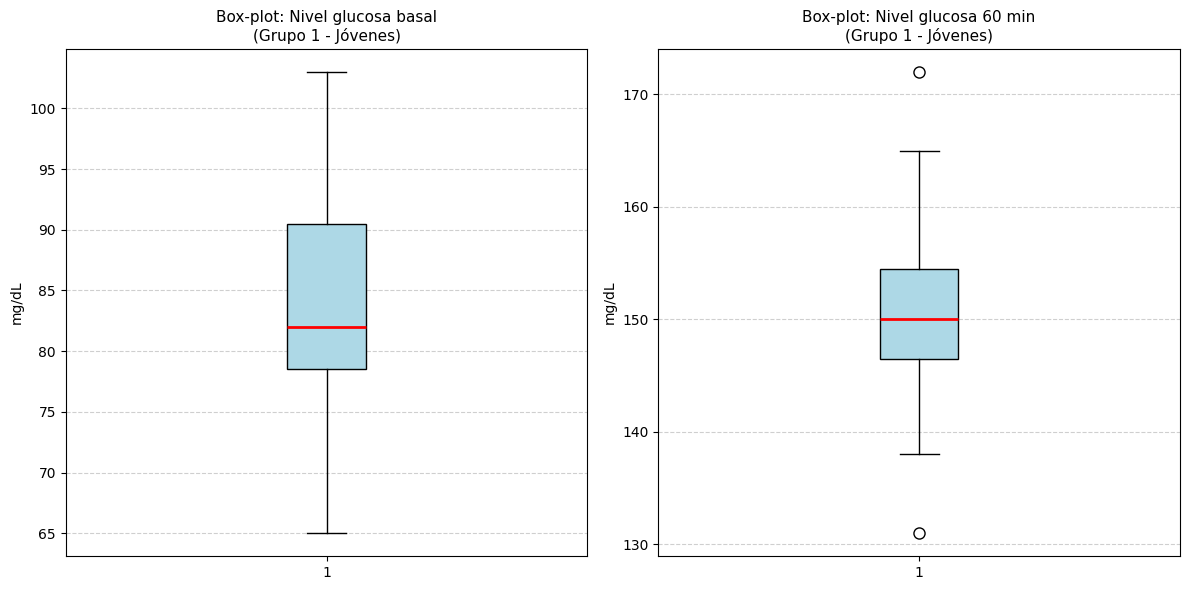

In [9]:
variables = ['Nivel glucosa basal', 'Nivel glucosa 60 min']

for var in variables:
    q1 = grupo_1[var].quantile(0.25)
    q2 = grupo_1[var].quantile(0.50)
    q3 = grupo_1[var].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    atipicos = grupo_1[(grupo_1[var] < lim_inf) | (grupo_1[var] > lim_sup)][var]

    print(f"--- {var} (Group 1) ---")
    print(f"  Q1 (25%): {q1:.2f} mg/dL")
    print(f"  Q2 (50%) - Median: {q2:.2f} mg/dL")
    print(f"  Q3 (75%): {q3:.2f} mg/dL")
    print(f"  IQR: {iqr:.2f} mg/dL")
    print(f"  Lower bound (Q1 - 1.5·IQR): {lim_inf:.2f}")
    print(f"  Upper bound (Q3 + 1.5·IQR): {lim_sup:.2f}")
    if atipicos.empty:
        print("  Outliers: None")
    else:
        print(f"  Outliers: {atipicos.values}")
    print()

# Box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, var in zip(axes, variables):
    ax.boxplot(grupo_1[var].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='red', markersize=8))
    ax.set_title(f'Box plot: {var}\n(Group 1 - Young)', fontsize=11)
    ax.set_ylabel('mg/dL')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()




### Quartile interpretation — Group 1 (Young)

---

#### Variable: Nivel glucosa basal

| Statistic | Value | Meaning |
|---|---|---|
| Q1 (25%) | 78.50 mg/dL | 25% of young patients have a basal level ≤ 78.50 mg/dL |
| Q2 – Median (50%) | 82.00 mg/dL | Half of young patients have a basal level ≤ 82 mg/dL |
| Q3 (75%) | 90.50 mg/dL | 75% of young patients have a basal level ≤ 90.50 mg/dL |
| IQR | 12.00 mg/dL | The central 50% of the data is concentrated in a range of 12 mg/dL, indicating low dispersion |

**Outliers:** No outliers are detected. All data points fall within the bounds [60.50, 108.50] mg/dL. The distribution is homogeneous with no extreme observations.

---

#### Variable: Nivel glucosa 60 min

| Statistic | Value | Meaning |
|---|---|---|
| Q1 (25%) | 146.50 mg/dL | 25% of young patients have a 60-min level ≤ 146.50 mg/dL |
| Q2 – Median (50%) | 150.00 mg/dL | Half of young patients have a 60-min level ≤ 150 mg/dL |
| Q3 (75%) | 154.50 mg/dL | 75% of young patients have a 60-min level ≤ 154.50 mg/dL |
| IQR | 8.00 mg/dL | The central 50% is grouped in just 8 mg/dL, reflecting a very compact distribution |

**Outliers:** **2 outliers** are detected: **172 mg/dL** (above the upper bound of 166.50) and **131 mg/dL** (below the lower bound of 134.50). Both values clearly stand out as isolated points on the box plot. They could result from individual biological variability or measurement errors, and warrant review before proceeding with inferential analysis.



## d) Normality test — Nivel glucosa 60 min

H₀ is rejected if the p-value < 0.05 (α = 0.05).

The normality hypothesis is tested for both groups using the **Shapiro-Wilk test**, complemented with a histogram and a Q-Q plot for visual inspection.

- **H₁**: the data does not follow a normal distribution
- **H₀**: the data follows a normal distribution

Grupo 1 (Jóvenes) — Test de Shapiro-Wilk:
  Estadístico W = 0.9626
  p-valor       = 0.2734
  Conclusión (α=0.05): NO se rechaza H₀ → los datos siguen una distribución normal

Grupo 2 (Adultos) — Test de Shapiro-Wilk:
  Estadístico W = 0.9776
  p-valor       = 0.7592
  Conclusión (α=0.05): NO se rechaza H₀ → los datos siguen una distribución normal



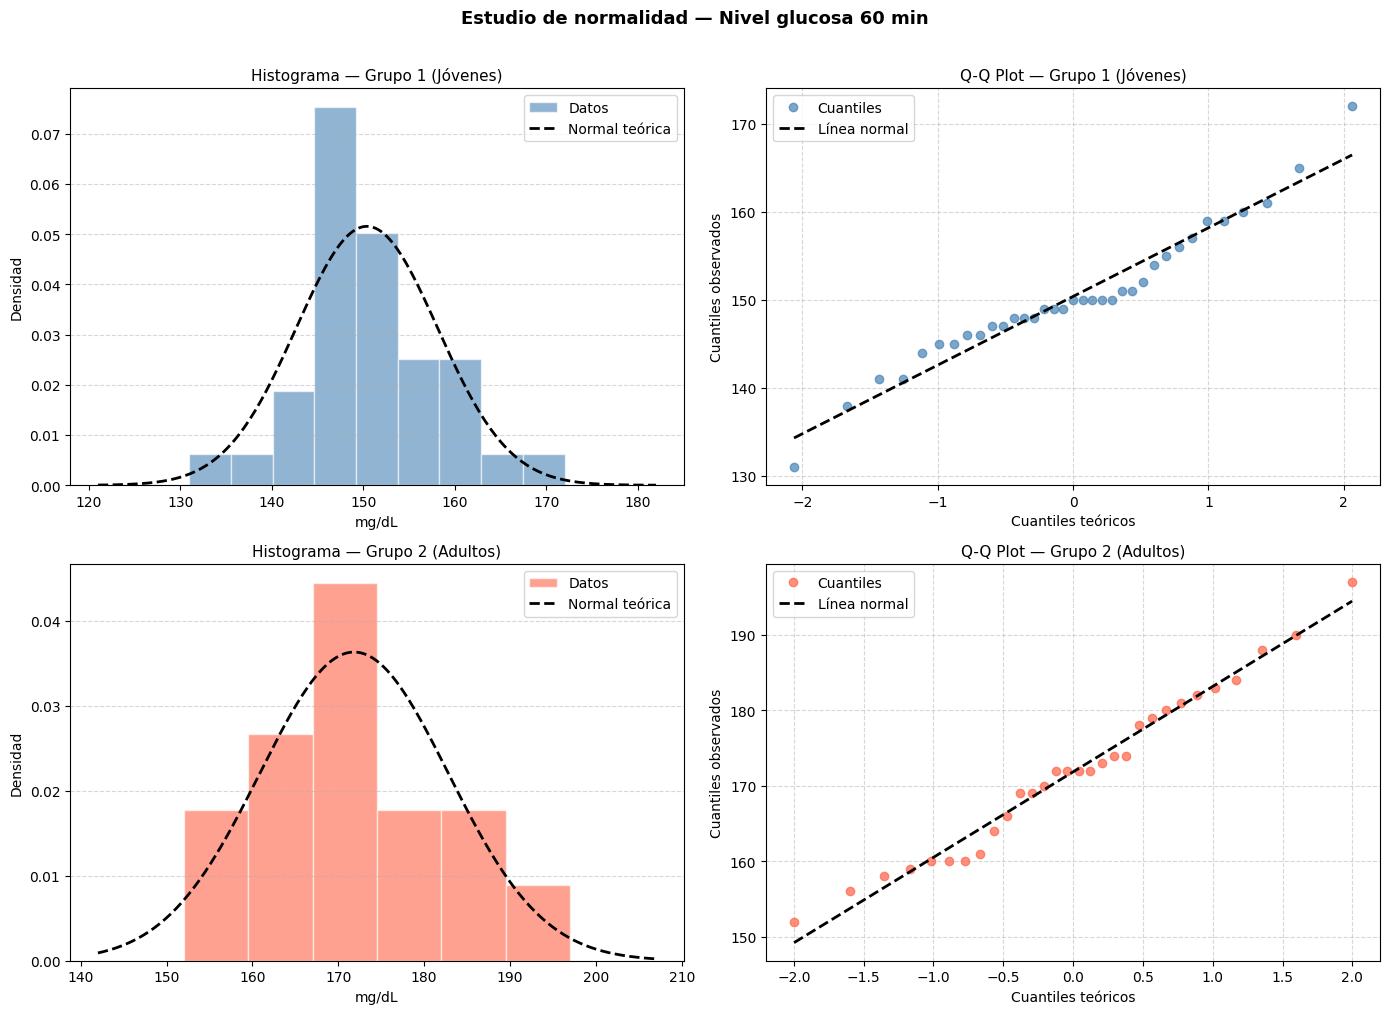

In [10]:
var = 'Nivel glucosa 60 min'
grupos = {'Group 1 (Young)': grupo_1, 'Group 2 (Adults)': grupo_2}
colores = ['steelblue', 'tomato']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (nombre, grupo) in enumerate(grupos.items()):
    datos = grupo[var].dropna()

    # Histogram + normal curve
    ax1 = axes[i, 0]
    mu, sigma = datos.mean(), datos.std()
    x = np.linspace(datos.min() - 10, datos.max() + 10, 200)
    ax1.hist(datos, bins='auto', density=True, color=colores[i], alpha=0.6, edgecolor='white', label='Data')
    ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', linewidth=2, label='Theoretical normal')
    ax1.set_title(f'Histogram — {nombre}', fontsize=11)
    ax1.set_xlabel('mg/dL')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # Q-Q plot
    ax2 = axes[i, 1]
    (osm, osr), (slope, intercept, r) = stats.probplot(datos, dist='norm')
    ax2.plot(osm, osr, 'o', color=colores[i], alpha=0.7, label='Quantiles')
    ax2.plot(osm, slope * np.array(osm) + intercept, 'k--', linewidth=2, label='Normal line')
    ax2.set_title(f'Q-Q Plot — {nombre}', fontsize=11)
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Observed quantiles')
    ax2.legend()
    ax2.grid(linestyle='--', alpha=0.5)

    # Shapiro-Wilk test
    stat, p_value = stats.shapiro(datos)
    print(f"{nombre} — Shapiro-Wilk test:")
    print(f"  Statistic W = {stat:.4f}")
    print(f"  p-value     = {p_value:.4f}")
    conclusion = "H₀ is NOT rejected → the data follows a normal distribution" if p_value > 0.05 else "H₀ is REJECTED → the data does NOT follow a normal distribution"
    print(f"  Conclusion (α=0.05): {conclusion}\n")

plt.suptitle(f'Normality test — {var}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()




**Shapiro-Wilk test results:**

| Group | W | p-value | Conclusion |
|---|---|---|---|
| Group 1 (Young) | 0.9626 | 0.2734 | H₀ not rejected |
| Group 2 (Adults) | 0.9776 | 0.7592 | H₀ not rejected |

In both groups the p-value is greater than 0.05, and the Q-Q plots show that the points fit the theoretical line.

**Conclusion:** The data from both groups is compatible with a normal distribution (α = 0.05). This result allows parametric tests to be applied in subsequent analyses.



---

# Part 2: Linear Regression

Using the data above, the relationship between the basal level and the glucose level at 60 minutes is studied for Group 1 (young). Normality is assumed for both variables (verified in Part 1d).

## a) Linear relationship between the basal level and the 60-min glucose level

The relationship between the two variables is analyzed graphically with a scatter plot and quantified with the **Pearson correlation coefficient** ($r$).

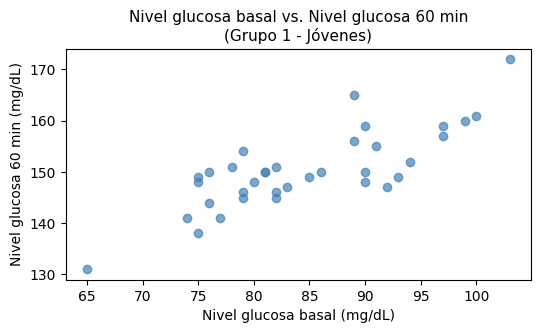

In [11]:
fig = plt.figure(figsize=(6, 3))
plt.scatter(grupo_1['Nivel glucosa basal'], grupo_1['Nivel glucosa 60 min'], color='steelblue', alpha=0.7, label='Group 1 (Young)')
plt.title('Nivel glucosa basal vs. Nivel glucosa 60 min\n(Group 1 - Young)', fontsize=11)
plt.xlabel('Nivel glucosa basal (mg/dL)')
plt.ylabel('Nivel glucosa 60 min (mg/dL)')
plt.show()

In [12]:
coef_correlacion_1 = np.corrcoef(grupo_1['Nivel glucosa basal'], grupo_1['Nivel glucosa 60 min'])[0, 1]
print(f"Correlation coefficient (Group 1): {coef_correlacion_1:.4f}")

Coeficiente de correlación (Grupo 1): 0.7964


The Pearson correlation coefficient obtained is **r = 0.7965**, indicating a strong positive linear correlation between the basal level and the 60-min glucose level. The scatter plot visually confirms this increasing trend.

**Conclusion:** There is a significant positive linear relationship between both variables in Group 1 (young).

## b) Simple linear regression model

An ordinary least squares (OLS) linear regression model is fit with *glucose level at 60 min* as the dependent variable and *basal level* as the independent variable. The glucose level is estimated for a patient with a basal level of 83 mg/dL.


Estimación para nivel basal = 83 mg/dL:
Glucosa a los 60 min ≈ 149.23 mg/dL


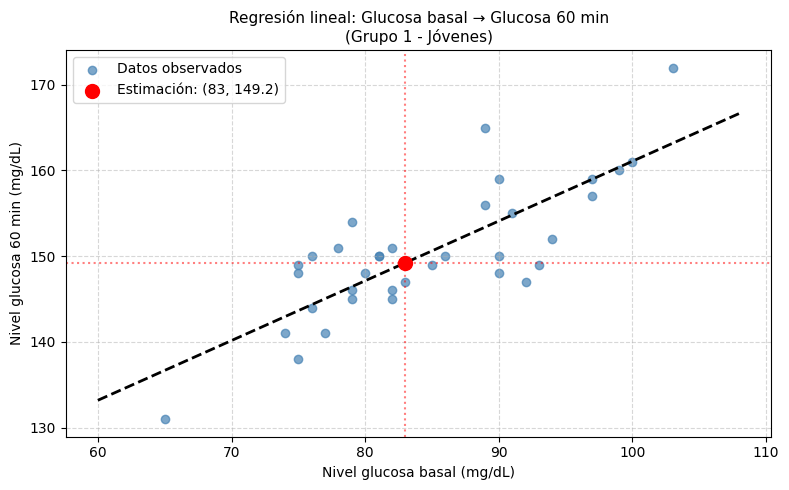

In [13]:
X = grupo_1['Nivel glucosa basal']
y = grupo_1['Nivel glucosa 60 min']

X_const = sm.add_constant(X)
modelo = sm.OLS(y, X_const).fit()

# Estimate for basal level = 83 mg/dL
nivel_basal = 83
prediccion = modelo.predict([1, nivel_basal])[0]
print(f"\nEstimate for basal level = {nivel_basal} mg/dL:")
print(f"Glucose at 60 min ≈ {prediccion:.2f} mg/dL")

# Plot
b0 = modelo.params['const']
b1 = modelo.params['Nivel glucosa basal']
r2 = modelo.rsquared

x_range = np.linspace(X.min() - 5, X.max() + 5, 200)
y_pred_range = b0 + b1 * x_range

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X, y, color='steelblue', alpha=0.7, label='Observed data')
ax.plot(x_range, y_pred_range, 'k--', linewidth=2)
ax.scatter(nivel_basal, prediccion, color='red', zorder=5, s=100,
           label=f'Estimate: ({nivel_basal}, {prediccion:.1f})')
ax.axvline(nivel_basal, color='red', linestyle=':', alpha=0.5)
ax.axhline(prediccion, color='red', linestyle=':', alpha=0.5)
ax.set_title('Linear regression: Basal glucose → 60-min glucose\n(Group 1 - Young)', fontsize=11)
ax.set_xlabel('Nivel glucosa basal (mg/dL)')
ax.set_ylabel('Nivel glucosa 60 min (mg/dL)')
ax.legend()
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



**Model obtained:**

$$\hat{Y} = 91.3837 + 0.6969 \cdot X$$

where $X$ is the basal glucose level (mg/dL) and $\hat{Y}$ is the estimated level at 60 min (mg/dL).

| Parameter | Value | Interpretation |
|---|---|---|
| β₀ (intercept) | 91.38 mg/dL | Value of the dependent variable when X = 0 (theoretical value) |
| β₁ (slope) | 0.6969 | For each additional mg/dL of basal glucose, the 60-min glucose increases by 0.70 mg/dL |

**Estimate for basal level = 83 mg/dL:**

$$\hat{Y} = 91.3837 + 0.6969 \times 83 \approx 149.23 \text{ mg/dL}$$

**Conclusion:** A young patient with a basal level of 83 mg/dL is estimated to have a glucose level of approximately **149.23 mg/dL** one hour after intake.

## c) Variance not explained by the model

The coefficient of determination R² indicates what percentage of the dependent variable's variability is explained by the model. Its complement (1 − R²) represents the variance **not explained**.

In [14]:
print(modelo.summary())
r2 = modelo.rsquared
print(f"Model R²: {r2:.4f}")

                             OLS Regression Results                             
Dep. Variable:     Nivel glucosa 60 min   R-squared:                       0.634
Model:                              OLS   Adj. R-squared:                  0.623
Method:                   Least Squares   F-statistic:                     57.23
Date:                  Sun, 26 Apr 2026   Prob (F-statistic):           1.06e-08
Time:                          22:06:54   Log-Likelihood:                -103.17
No. Observations:                    35   AIC:                             210.3
Df Residuals:                        33   BIC:                             213.5
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

The coefficient of determination obtained is **R² = 0.6343**, indicating that the model explains **63.43%** of the variability in the 60-min glucose level.

**Conclusion:** The **remaining 36.57%** of the variability is not explained by the basal level. Other factors (individual metabolism, physical condition, diet) influence the glycemic response and are not captured by the model.

## d) Change in glucose level for an increase in the basal level

Given the fitted model, the slope β₁ directly quantifies the change in the dependent variable for each unit increase in the independent variable.

In [15]:

b1 = modelo.params['Nivel glucosa basal']
incremento_basal = 5
variacion_60min = b1 * incremento_basal

print(f"Model slope (β₁): {b1:.4f}")
print(f"Increase in basal level: {incremento_basal} mg/dL")
print(f"Estimated change in 60-min glucose: {variacion_60min:.4f} mg/dL")



Pendiente del modelo (β₁): 0.6969
Incremento en nivel basal: 5 mg/dL
Variación estimada en glucosa a los 60 min: 3.4844 mg/dL


$$\Delta \hat{Y} = \beta_1 \cdot \Delta X = 0.6969 \times 5 = 3.4844 \text{ mg/dL}$$

**Conclusion:** A 5 mg/dL increase in the basal level produces an estimated **3.48 mg/dL** increase in the 60-min glucose level, regardless of the starting basal value.

---

# Part 3: Confidence Intervals and Hypothesis Testing

## a) Confidence interval for the mean — Group 1

Confidence intervals are constructed for the population mean of basal glucose in Group 1 (young). Since the population variance is unknown and normality was verified (Part 1d), the **Student's t-distribution** with n − 1 degrees of freedom is used.

Additionally, at α = 0.05, it is tested whether the population mean could be μ = 88 mg/dL.

In [16]:

datos = grupo_1['Nivel glucosa basal'].dropna()
n = len(datos)
media = datos.mean()
desv = datos.std(ddof=1)
mu_0 = 88  # value to test

# Confidence intervals using Student's t (unknown sigma)
ic_95 = stats.t.interval(0.95, df=n-1, loc=media, scale=stats.sem(datos))
ic_99 = stats.t.interval(0.99, df=n-1, loc=media, scale=stats.sem(datos))

print(f"n = {n},  sample mean = {media:.4f},  std dev = {desv:.4f}")
print(f"\n95% CI: [{ic_95[0]:.4f}, {ic_95[1]:.4f}] mg/dL  →  {mu_0} mg/dL {'∈' if ic_95[0] <= mu_0 <= ic_95[1] else '∉'} CI → {'μ=88 is admissible' if ic_95[0] <= mu_0 <= ic_95[1] else 'μ=88 is not admissible'}")
print(f"99% CI: [{ic_99[0]:.4f}, {ic_99[1]:.4f}] mg/dL  →  {mu_0} mg/dL {'∈' if ic_99[0] <= mu_0 <= ic_99[1] else '∉'} CI → {'μ=88 is admissible' if ic_99[0] <= mu_0 <= ic_99[1] else 'μ=88 is not admissible'}")



n = 35,  media muestral = 84.6857,  desv. típica = 8.8443

IC 95%: [81.6476, 87.7238] mg/dL  →  88 mg/dL ∉ IC → No se admite μ=88
IC 99%: [80.6069, 88.7646] mg/dL  →  88 mg/dL ∈ IC → Se admite μ=88


| Confidence level | Lower bound | Upper bound | μ = 88 mg/dL ∈ CI? |
|---|---|---|---|
| 95% | 81.65 | 87.72 | No |
| 99% | 80.61 | 88.76 | Yes |

**Conclusion:** At α = 0.05 (95% CI), the value 88 mg/dL is **outside** the interval, so **H₀: μ = 88 is rejected**. At α = 0.01 (99% CI), the value 88 falls **within** the interval and H₀ cannot be rejected.

## b) Confidence interval for the difference of means

A 95% CI is constructed for the difference μ₁ − μ₂ (Group 1 − Group 2) in the basal glucose level. Since equal variances are not assumed, the **Welch** approximation is applied. If 0 ∉ CI, the means are concluded to differ significantly.

In [17]:

d1 = grupo_1['Nivel glucosa basal'].dropna()
d2 = grupo_2['Nivel glucosa basal'].dropna()

n1, n2 = len(d1), len(d2)
media1, media2 = d1.mean(), d2.mean()
dif_medias = media1 - media2

# 95% CI for the difference of means (independent samples, unknown variances)
# ttest_ind is used to obtain the equivalent CI with equal_var=False (Welch)
t_stat, p_val = stats.ttest_ind(d1, d2, equal_var=False)
resultado = stats.ttest_ind(d1, d2, equal_var=False)

# Manual CI calculation using Welch
s1, s2 = d1.std(ddof=1), d2.std(ddof=1)
se = np.sqrt(s1**2/n1 + s2**2/n2)
# Welch degrees of freedom
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df=df_welch)
ic_dif = (dif_medias - t_crit * se, dif_medias + t_crit * se)

print(f"Group 1 (Young): n={n1}, mean={media1:.4f}, s={s1:.4f}")
print(f"Group 2 (Adults): n={n2}, mean={media2:.4f}, s={s2:.4f}")
print(f"\nDifference of means (μ₁ - μ₂): {dif_medias:.4f} mg/dL")
print(f"\n95% CI for (μ₁ - μ₂): [{ic_dif[0]:.4f}, {ic_dif[1]:.4f}] mg/dL")
print(f"\n0 {'∈' if ic_dif[0] <= 0 <= ic_dif[1] else '∉'} CI → {'H₀ not rejected: the means are equal' if ic_dif[0] <= 0 <= ic_dif[1] else 'H₀ rejected: the means differ'}")



Grupo 1 (Jóvenes): n=35, media=84.6857, s=8.8443
Grupo 2 (Adultos):  n=30, media=89.4000, s=7.3466

Diferencia de medias (μ₁ - μ₂): -4.7143 mg/dL

IC 95% para (μ₁ - μ₂): [-8.7280, -0.7006] mg/dL

0 ∉ IC → Se rechaza H₀: las medias son distintas


| Group | Mean (mg/dL) | n |
|---|---|---|
| Group 1 — Young | 84.69 | 35 |
| Group 2 — Adults | 89.40 | 30 |

**95% CI for (μ₁ − μ₂): [−8.73, −0.70] mg/dL**

**Conclusion:** The value 0 does not belong to the confidence interval, so **H₀: μ₁ = μ₂ is rejected** at α = 0.05. Group 2 (adults) shows a significantly higher basal glucose level than Group 1 (young).

## c) Confidence interval for the proportion of prediabetes

A 98% CI is constructed for the proportion of individuals in the overall sample with a basal glucose level > 95 mg/dL. At α = 0.05, the hypothesis H₀: p = 0.15 is tested against H₁: p ≠ 0.15.

In [18]:
# All the data
todos = df['Nivel glucosa basal'].dropna()
n = len(todos)
exitos = (todos > 95).sum() # Number of patients with glucose > 95 mg/dL
p_hat = exitos / n

print(f"Total patients (n): {n}")
print(f"Patients with glucose > 95 mg/dL: {exitos}")
print(f"Sample proportion (p̂): {p_hat:.4f}")

# 98% CI (normal approximation)
# proportion_confint returns (lower bound, upper bound) of the confidence interval for the proportion
# alpha=0.02 corresponds to a 98% confidence level (1 - alpha = 0.98)
ic_98 = proportion_confint(exitos, n, alpha=0.02, method='normal')
print(f"\n98% CI: [{ic_98[0]:.4f}, {ic_98[1]:.4f}]")

# Test H₀: p = 0.15  vs  H₁: p ≠ 0.15  (α = 0.05)
p_0 = 0.15
# alpha=0.05 for a two-tailed test, so alpha=0.05 is used in proportion_confint to obtain
# the 95% CI that corresponds to the test
ic_95 = proportion_confint(exitos, n, alpha=0.05, method='normal')

print(f"\nTest H₀: p = {p_0}  vs  H₁: p ≠ {p_0}  (α = 0.05)")
print(f"  95% CI: [{ic_95[0]:.4f}, {ic_95[1]:.4f}]")
print(f"\n  {p_0} {'∈' if ic_95[0] <= p_0 <= ic_95[1] else '∉'} 95% CI → {'H₀ not rejected: p = 0.15 is admissible' if ic_95[0] <= p_0 <= ic_95[1] else 'H₀ rejected: p ≠ 0.15'}")



Total pacientes (n): 65
Pacientes con glucosa > 95 mg/dL: 11
Proporción muestral (p̂): 0.1692

IC 98%: [0.0610, 0.2774]

Contraste H₀: p = 0.15  vs  H₁: p ≠ 0.15  (α = 0.05)
  IC 95%: [0.0781, 0.2604]

  0.15 ∈ IC 95% → No se rechaza H₀: p = 0.15 es admisible


The **normal approximation for proportions** is applied (valid since n·p̂ = 11 ≥ 5 and n·(1−p̂) = 54 ≥ 5).

$$\hat{p} \pm z_{0.01} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}} = 0.1692 \pm 2.326 \cdot \sqrt{\frac{0.1692 \cdot 0.8308}{65}}$$

| Total n | Patients > 95 mg/dL | p̂ | 98% CI |
|---|---|---|---|
| 65 | 11 | 0.1692 | [0.0610, 0.2774] |

**Test H₀: p = 0.15 vs. H₁: p ≠ 0.15 (α = 0.05)**

Since 0.15 ∈ 95% CI = [0.0781, 0.2604] and the p-value (0.6792) > 0.05:

**Conclusion:** H₀ is not rejected. The data is compatible with a prediabetes proportion in the population of **p = 0.15** at the 5% significance level.